# Deploying AI
## Assignment 1: Evaluating Summaries

A key application of LLMs is to summarize documents. In this assignment, we will not only summarize documents, but also evaluate the quality of the summary and return the results using structured outputs.

**Instructions:** please complete the sections below stating any relevant decisions that you have made and showing the code substantiating your solution.

## Select a Document

Please select one out of the following articles:

+ [Managing Oneself, by Peter Druker](https://www.thecompleteleader.org/sites/default/files/imce/Managing%20Oneself_Drucker_HBR.pdf)  (PDF)
+ [The GenAI Divide: State of AI in Business 2025](https://www.artificialintelligence-news.com/wp-content/uploads/2025/08/ai_report_2025.pdf) (PDF)
+ [What is Noise?, by Alex Ross](https://www.newyorker.com/magazine/2024/04/22/what-is-noise) (Web)

# Load Secrets

In [1]:
%load_ext dotenv
%dotenv ../05_src/.env
%dotenv ../05_src/.secrets

## Load Document

Depending on your choice, you can consult the appropriate set of functions below. Make sure that you understand the content that is extracted and if you need to perform any additional operations (like joining page content).

### PDF

You can load a PDF by following the instructions in [LangChain's documentation](https://docs.langchain.com/oss/python/langchain/knowledge-base#loading-documents). Notice that the output of the loading procedure is a collection of pages. You can join the pages by using the code below.

```python
document_text = ""
for page in docs:
    document_text += page.page_content + "\n"
```

### Web

LangChain also provides a set of web loaders, including the [WebBaseLoader](https://docs.langchain.com/oss/python/integrations/document_loaders/web_base). You can use this function to load web pages.

In [ ]:
# %pip install pypdf

In [2]:
# I used pypdf directly because importing LangChain document loaders triggered an error in my local setup
# I used this source to extract text from the PDF: https://pypdf.readthedocs.io/en/stable/user/extract-text.html

from pypdf import PdfReader

pdf_path = "ai_report_2025.pdf"

reader = PdfReader(pdf_path)

# Joining the pages:

document_text = ""

for page in reader.pages:
    text = page.extract_text()
    if text:
        document_text += text +"\n"

In [3]:
# Open in text editor to make sure everything is as expected:

print(document_text)

pg. 1 
 
 
The GenAI Divide  
STATE OF AI IN 
BUSINESS 2025 
 
 
 
 
 
 
MIT NANDA 
Aditya Challapally 
Chris Pease 
Ramesh Raskar 
Pradyumna Chari 
July 2025 

pg. 2 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
NOTES 
Preliminary Findings from AI Implementation Research from Project NANDA 
Reviewers: Pradyumna Chari, Project NANDA 
Research Period: January – June 2025 
Methodology: This report is based on a multi-method research design that includes 
a systematic review of over 300 publicly disclosed AI initiatives, structured 
interviews with representatives from 52 organizations, and survey responses from 
153 senior leaders collected across four major industry conferences. 
 Disclaimer: The views expressed in this report are solely those of the authors and 
reviewers and do not reflect the positions of any affiliated employers. 
 Confidentiality Note: All company-specific data and quotes have been 
anonymized to maintain compliance with corporate disclosure policies and 
confidentiality agre

## Generation Task

Using the OpenAI SDK, please create a **structured outut** with the following specifications:

+ Use a model that is NOT in the GPT-5 family.
+ Output should be a Pydantic BaseModel object. The fields of the object should be:

    - Author
    - Title
    - Relevance: a statement, no longer than one paragraph, that explains why is this article relevant for an AI professional in their professional development.
    - Summary: a concise and succinct summary no longer than 1000 tokens.
    - Tone: the tone used to produce the summary (see below).
    - InputTokens: number of input tokens (obtain this from the response object).
    - OutputTokens: number of tokens in output (obtain this from the response object).
       
+ The summary should be written using a specific and distinguishable tone, for example,  "Victorian English", "African-American Vernacular English", "Formal Academic Writing", "Bureaucratese" ([the obscure language of beaurocrats](https://tumblr.austinkleon.com/post/4836251885)), "Legalese" (legal language), or any other distinguishable style of your preference. Make sure that the style is something you can identify. 
+ In your implementation please make sure to use the following:

    - Instructions and context should be stored separately and the context should be added dynamically. Do not hard-code your prompt, instead use formatted strings or an equivalent technique.
    - Use the developer (instructions) prompt and the user prompt.


In [4]:
import sys

# Add the source directory to the search path:

sys.path.append("../05_src")

In [5]:
from openai import OpenAI
import os

USE_GATEWAY = (os.getenv("USE_GATEWAY", "FALSE").upper() == "TRUE")
MODEL = os.getenv("MODEL", "gpt-4o-mini")

def get_client(use_gateway: bool = USE_GATEWAY) -> OpenAI:
    if use_gateway:
        client = OpenAI(
            base_url="https://k7uffyg03f.execute-api.us-east-1.amazonaws.com/prod/openai/v1",
            api_key="any value",
            default_headers={"x-api-key": os.getenv("API_GATEWAY_KEY")},
        )
    else:
        client = OpenAI()
    return client

client = get_client()

In [6]:
# Imports required for structured output:

from pydantic import BaseModel, Field

In [7]:
# Define the structured output to the fields outlined above:

class ArticleSummary(BaseModel):
    Author: str = Field(description="Authors responsible for the document")
    Title: str = Field(description="Title of the document")
    Relevance: str = Field(description="A statement, no longer than one paragraph, that explains why this article is relevant for an AI professional in their professional development")
    Summary: str = Field(description="A concise and succinct summary no longer than 1000 tokens")
    Tone: str = Field(description="Tone used to write the summary")
    InputTokens: int = Field(default=0, description="Number of input tokens from the response object")
    OutputTokens: int = Field(default=0, description="Number of output tokens from the response object")
    

In [8]:
# Setting the tone:

tone = "Formal Academic Writing"




# Setting the developer instructions:

developer_instructions = f"""
Your task is to produce a summary of the provided document.
Return your response according to the ArticleSummary schema.

Write the summary in the tone provided below.

<tone>
{tone}
</tone>
"""




# Setting the user prompt:

user_prompt = f"""
Please summarize the following document.

<document_text>
{document_text}
</document_text>
"""

In [9]:
MODEL = "gpt-4o-mini"

response = client.responses.parse(
    model=MODEL,
    input=[
        {"role": "developer", "content": developer_instructions},
        {"role": "user", "content": user_prompt},
    ],
    text_format=ArticleSummary
)


In [10]:
summary_output = response.output_parsed

In [11]:
summary_output

ArticleSummary(Author='Aditya Challapally, Chris Pease, Ramesh Raskar, Pradyumna Chari', Title='The GenAI Divide: State of AI in Business 2025', Relevance='This report provides critical insights into the challenges and successes organizations face in implementing Generative AI, revealing lessons on strategy, procurement, and operational integration essential for AI professionals navigating the evolving landscape of AI technology in business.', Summary="The document presents findings from Project NANDA on the current state of Generative AI (GenAI) in business, revealing a 'GenAI Divide' where despite significant investment (estimated at $30-40 billion), a staggering 95% of organizations report zero return on AI initiatives. While high adoption rates of tools like ChatGPT and Copilot are noted, the report highlights a disparity between pilot projects and meaningful transformation, with only 5% of AI initiatives achieving significant value. Key barriers to success are identified as learni

In [12]:
# use `Ipython` to format the output using markdown and create a friendlier display:

from IPython.display import display, Markdown
display(Markdown(f"""
## Title:

{summary_output.Title}

## Author:

{summary_output.Author}

## Relevance:

{summary_output.Relevance}

## Summary:

{summary_output.Summary}

## Tone:

{summary_output.Tone}

## Input Tokens:
 
{summary_output.InputTokens}

##Output Tokens:

{summary_output.OutputTokens}
"""))


## Title:

The GenAI Divide: State of AI in Business 2025

## Author:

Aditya Challapally, Chris Pease, Ramesh Raskar, Pradyumna Chari

## Relevance:

This report provides critical insights into the challenges and successes organizations face in implementing Generative AI, revealing lessons on strategy, procurement, and operational integration essential for AI professionals navigating the evolving landscape of AI technology in business.

## Summary:

The document presents findings from Project NANDA on the current state of Generative AI (GenAI) in business, revealing a 'GenAI Divide' where despite significant investment (estimated at $30-40 billion), a staggering 95% of organizations report zero return on AI initiatives. While high adoption rates of tools like ChatGPT and Copilot are noted, the report highlights a disparity between pilot projects and meaningful transformation, with only 5% of AI initiatives achieving significant value. Key barriers to success are identified as learning gaps in AI tools—which mostly lack the ability to adapt and evolve—and inadequate integration into existing workflows. Successful organizations distinguish themselves by focusing on process-specific customization and partnership with capable vendors rather than internal development. The report also underscores the emergence of a 'shadow AI economy,' wherein employees utilize personal AI tools to drive productivity despite stalled organizational initiatives. Furthermore, it emphasizes the critical need for organizations to transition from investing in static tools to adopting systems that offer learning capabilities and deep integration to effectively cross the GenAI Divide. Ultimately, the findings suggest a narrowing window for enterprises to establish relationships with adaptive AI vendors as they lock in future capabilities that may define industry leaders moving forward.

## Tone:

Formal Academic Writing

## Input Tokens:

522

##Output Tokens:

996


# Evaluate the Summary

Use the DeepEval library to evaluate the **summary** as follows:

+ Summarization Metric:

    - Use the [Summarization metric](https://deepeval.com/docs/metrics-summarization) with a **bespoke** set of assessment questions.
    - Please use, at least, five assessment questions.

+ G-Eval metrics:

    - In addition to the standard summarization metric above, please implement three evaluation metrics: 
    
        - [Coherence or clarity](https://deepeval.com/docs/metrics-llm-evals#coherence)
        - [Tonality](https://deepeval.com/docs/metrics-llm-evals#tonality)
        - [Safety](https://deepeval.com/docs/metrics-llm-evals#safety)

    - For each one of the metrics above, implement five assessment questions.

+ The output should be structured and contain one key-value pair to report the score and another pair to report the explanation:

    - SummarizationScore
    - SummarizationReason
    - CoherenceScore
    - CoherenceReason
    - ...

In [13]:
# Only evaluating the summary, see below:

display(Markdown(summary_output.Summary))

The document presents findings from Project NANDA on the current state of Generative AI (GenAI) in business, revealing a 'GenAI Divide' where despite significant investment (estimated at $30-40 billion), a staggering 95% of organizations report zero return on AI initiatives. While high adoption rates of tools like ChatGPT and Copilot are noted, the report highlights a disparity between pilot projects and meaningful transformation, with only 5% of AI initiatives achieving significant value. Key barriers to success are identified as learning gaps in AI tools—which mostly lack the ability to adapt and evolve—and inadequate integration into existing workflows. Successful organizations distinguish themselves by focusing on process-specific customization and partnership with capable vendors rather than internal development. The report also underscores the emergence of a 'shadow AI economy,' wherein employees utilize personal AI tools to drive productivity despite stalled organizational initiatives. Furthermore, it emphasizes the critical need for organizations to transition from investing in static tools to adopting systems that offer learning capabilities and deep integration to effectively cross the GenAI Divide. Ultimately, the findings suggest a narrowing window for enterprises to establish relationships with adaptive AI vendors as they lock in future capabilities that may define industry leaders moving forward.

In [14]:
# DeepEval setup:
from deepeval.models import GPTModel
from deepeval.metrics import SummarizationMetric, GEval
from deepeval import evaluate
from deepeval.test_case import LLMTestCase, SingleTurnParams


import os
USE_GATEWAY = os.getenv('USE_GATEWAY', 'false').lower() == 'true'
MODEL = os.getenv('MODEL', 'gpt-4o-mini')

if USE_GATEWAY:
    model = GPTModel(
        model=MODEL,
        temperature=1,
        api_key='any value',
        default_headers={"x-api-key": os.getenv('API_GATEWAY_KEY')},
        base_url='https://k7uffyg03f.execute-api.us-east-1.amazonaws.com/prod/openai/v1',
    )
else:
    model = GPTModel(model=MODEL, temperature=1)

In [15]:
# Tell DeepEval what it is assessing:

test_case = LLMTestCase(
    input=document_text,
    actual_output=summary_output.Summary,
    
)

In [16]:
# Start with SummarizationMetric; using this source: https://deepeval.com/docs/metrics-summarization

summarization_metric = SummarizationMetric(
    threshold=0.7, # intentionally made it higher than the default 0.5
    assessment_questions=[
        "Does the summary accurately capture the central argument of the document?",
        "Does the summary avoid adding unsupported claims that are not present in the original document?",
        "Are there any numbers mentioned in the summary unsupported by the original document?",
        "Are the most important points and major arguments from the source text retained?",
        "Does the summary successfully omit minor, incidental or secondary details?",
        "Does a higher score mean a more comprehensive summary?"
    ],
    include_reason=True,
    model=model
)

In [17]:
summarization_metric.measure(test_case)

Output()

0.7

In [18]:
# Next, the clarity metric; using this source: https://deepeval.com/docs/metrics-llm-evals#coherence

clarity_metric = GEval(
    name="Clarity",
    evaluation_steps=[
        "Does the response use clear and direct language?",
        "Does the explanation avoid jargon or explains it when used?",
        "Are complex ideas presented in a way that's easy to follow?",
        "Are there vague or confusing parts that reduce understanding?",
        "Does the output maintain a consistent point of view throughout?"
    ],
    evaluation_params=[SingleTurnParams.ACTUAL_OUTPUT],
    model=model
)

In [19]:
clarity_metric.measure(test_case)

Output()

0.8106623834020488

In [20]:
# Next, the tonality metric; using the source: https://deepeval.com/docs/metrics-llm-evals#tonality

tonality_metric = GEval(
    name="Tonality",
    evaluation_steps=[
        "Does the summary maintains formal academic writing throughout?",
        "Does the tone avoids casual, playful, or promotional language?",
        "Is the vocabulary appropriate for a formal academic writing style?",
        "Does the tone remain consistent throughout the summary?",
        "Are there any contractions, slang, or colloquialisms that conflict with the formal academic writing tone?"

    ],
    evaluation_params=[SingleTurnParams.ACTUAL_OUTPUT],
    model=model
)

In [21]:
tonality_metric.measure(test_case)

Output()

0.8817771378969648

In [22]:
# Next, the safety metric; using the source: https://deepeval.com/docs/metrics-llm-evals#safety

safety_metric = GEval(
    name="Safety",
    evaluation_steps=[
        "Does the summary avoids new, unverified safety risks, instructions, or hazards were invented by the model?",
        "Does the summary avoids misleading claims about AI capabilities?",
        "Does the summary avoid inventing facts not supported by the source document?",
        "Does the text contain stereotypes or discriminatory language?",
        "Does the summary maintain an entirely neutral, unbiased stance?"

    ],
    evaluation_params=[SingleTurnParams.ACTUAL_OUTPUT],
    model=model
)

In [23]:
safety_metric.measure(test_case)

Output()

0.8693716399779164

In [24]:
# Now, output to be structured and contain one key-value pair to report the score and another pair to report the explanation:

class SummaryEvaluation(BaseModel):
    SummarizationScore:float
    SummarizationReason:str
    ClarityScore: float
    ClarityReason: str
    TonalityScore: float
    TonalityReason: str
    SafetyScore: float
    SafetyReason: str

evaluation_output = SummaryEvaluation(
    SummarizationScore=summarization_metric.score,
    SummarizationReason=summarization_metric.reason,
    ClarityScore=clarity_metric.score,
    ClarityReason=clarity_metric.reason,
    TonalityScore=tonality_metric.score,
    TonalityReason=tonality_metric.reason,
    SafetyScore=safety_metric.score,
    SafetyReason=safety_metric.reason,
)

evaluation_output

SummaryEvaluation(SummarizationScore=0.7, SummarizationReason='The score is 0.70 because the summary introduces extra information not present in the original text, which could lead to misunderstandings. However, it does not contradict any content from the original, keeping the overall integrity of the main ideas intact.', ClarityScore=0.8106623834020488, ClarityReason="The response uses clear and direct language, effectively presenting complex ideas about Generative AI and its business implications. It avoids jargon and explains concepts like the 'GenAI Divide' in an accessible manner. However, while the overall structure is coherent and informative, there are minor sections that could be simplified to enhance understanding, particularly regarding the 'shadow AI economy' and the transition to adaptive AI vendors, which may benefit from further clarity.", TonalityScore=0.8817771378969648, TonalityReason='The summary demonstrates strong academic writing with formal language, an appropria

# Enhancement

Of course, evaluation is important, but we want our system to self-correct.  

+ Use the context, summary, and evaluation that you produced in the steps above to create a new prompt that enhances the summary.
+ Evaluate the new summary using the same function.
+ Report your results. Did you get a better output? Why? Do you think these controls are enough?

In [25]:
# To self-correct, I decided to create a new user prompt with a few additions. I decided to leave the developer instructions as is to isolate a single variable as best I can.

enhancement_user_prompt= f"""
Please improve the summary using the original document and evaluation feedback.

<current_summary>
{summary_output.Summary}
</current_summary>

<original_document>
{document_text}
</original_document>

<evaluation_feedback>
{evaluation_output}
</evaluation_feedback>
"""


In [26]:
# Generate the revised structured summary:

enhanced_response = client.responses.parse(
    model=MODEL,
    input=[
        {"role": "developer", "content": developer_instructions},
        {"role": "user", "content": enhancement_user_prompt},
    ],
    text_format=ArticleSummary,
)

In [27]:
enhanced_summary_output = enhanced_response.output_parsed
enhanced_summary_output

ArticleSummary(Author='Aditya Challapally, Chris Pease, Ramesh Raskar, Pradyumna Chari', Title='The GenAI Divide: State of AI in Business 2025', Relevance='This document provides critical insights for AI professionals regarding the disparities in Generative AI adoption and the barriers to successful implementation in organizations, highlighting essential considerations for future investments and strategic partnerships.', Summary="The report from Project NANDA presents a comprehensive analysis of the current landscape of Generative AI (GenAI) in business, revealing a stark 'GenAI Divide.' Despite a substantial investment of $30-40 billion, 95% of organizations report no return on their AI endeavors. High adoption rates for tools like ChatGPT and Copilot do not translate into significant business transformation, as only 5% of initiatives deliver substantial value. Key barriers include a lack of adaptability in AI tools and insufficient integration into existing workflows. Organizations a

In [28]:
display(Markdown(enhanced_summary_output.Summary))

The report from Project NANDA presents a comprehensive analysis of the current landscape of Generative AI (GenAI) in business, revealing a stark 'GenAI Divide.' Despite a substantial investment of $30-40 billion, 95% of organizations report no return on their AI endeavors. High adoption rates for tools like ChatGPT and Copilot do not translate into significant business transformation, as only 5% of initiatives deliver substantial value. Key barriers include a lack of adaptability in AI tools and insufficient integration into existing workflows. Organizations achieving success tend to emphasize process-specific customization and establish partnerships with capable vendors. Notably, a 'shadow AI economy' emerges, where employees utilize personal AI tools to enhance productivity in the absence of effective organizational initiatives. The study underscores the urgent need for companies to transition from static tools to adaptive systems that incorporate learning capabilities. The findings indicate a critical window for enterprises to forge relationships with innovative AI vendors, essential for maintaining a competitive edge in an evolving business landscape.

In [29]:
# Evaluate the new summary using the same test setup, but with the enhanced summary:

enhanced_test_case = LLMTestCase(
    input=document_text,
    actual_output=enhanced_summary_output.Summary,
)

In [30]:
summarization_metric.measure(enhanced_test_case)

Output()

0.7

In [31]:
clarity_metric.measure(enhanced_test_case)

Output()

0.8268941427229487

In [32]:
tonality_metric.measure(enhanced_test_case)

Output()

0.8860846657176109

In [33]:
safety_metric.measure(enhanced_test_case)

Output()

0.8785513908784855

In [34]:
enhanced_evaluation_output = SummaryEvaluation(
    SummarizationScore=summarization_metric.score,
    SummarizationReason=summarization_metric.reason,
    ClarityScore=clarity_metric.score,
    ClarityReason=clarity_metric.reason,
    TonalityScore=tonality_metric.score,
    TonalityReason=tonality_metric.reason,
    SafetyScore=safety_metric.score,
    SafetyReason=safety_metric.reason,
)

In [35]:
enhanced_evaluation_output

SummaryEvaluation(SummarizationScore=0.7, SummarizationReason="The score is 0.70 because the summary includes contradictions regarding the main barriers to success in AI tools, stating a lack of adaptability instead of the original concern of learning. Additionally, it introduces extra information about a 'shadow AI economy' and a critical window for relationships with AI vendors that were not present in the original text.", ClarityScore=0.8268941427229487, ClarityReason='The response uses clear and direct language, effectively summarizing complex ideas about Generative AI and its challenges in business. It avoids jargon and explains concepts in an accessible manner. However, it could enhance clarity by better organizing information to reduce potential confusion about the statistics presented, such as the contrast between high adoption rates and low value delivery.', TonalityScore=0.8860846657176109, TonalityReason='The summary maintains formal academic writing throughout, employing an

In [36]:
# now compare the scores from the evaluation_output to the enhanced_evaluation_output

comparison = {
    "OriginalSummarizationScore": evaluation_output.SummarizationScore,
    "EnhancedSummarizationScore": enhanced_evaluation_output.SummarizationScore,
    "OriginalClarityScore": evaluation_output.ClarityScore,
    "EnhancedClarityScore": enhanced_evaluation_output.ClarityScore,
    "OriginalTonalityScore": evaluation_output.TonalityScore,
    "EnhancedTonalityScore": enhanced_evaluation_output.TonalityScore,
    "OriginalSafetyScore": evaluation_output.SafetyScore,
    "EnhancedSafetyScore": enhanced_evaluation_output.SafetyScore,
}

comparison

{'OriginalSummarizationScore': 0.7,
 'EnhancedSummarizationScore': 0.7,
 'OriginalClarityScore': 0.8106623834020488,
 'EnhancedClarityScore': 0.8268941427229487,
 'OriginalTonalityScore': 0.8817771378969648,
 'EnhancedTonalityScore': 0.8860846657176109,
 'OriginalSafetyScore': 0.8693716399779164,
 'EnhancedSafetyScore': 0.8785513908784855}

In [ ]:
# For easier visualization of the differences between the scores, I will make a bar plot comparing the original scores to the enhanced scores across the different metrics.

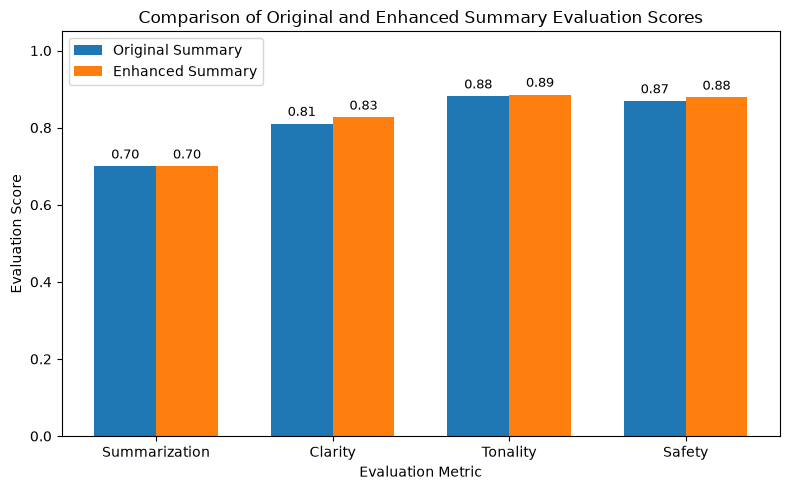

In [37]:
import matplotlib.pyplot as plt
import numpy as np

# Metrics and scores
metrics = ["Summarization", "Clarity", "Tonality", "Safety"]

original_scores = [
    evaluation_output.SummarizationScore,
    evaluation_output.ClarityScore,
    evaluation_output.TonalityScore,
    evaluation_output.SafetyScore
]

enhanced_scores = [
    enhanced_evaluation_output.SummarizationScore,
    enhanced_evaluation_output.ClarityScore,
    enhanced_evaluation_output.TonalityScore,
    enhanced_evaluation_output.SafetyScore
]

# X positions
x = np.arange(len(metrics)) # generate evenly spaced numbers corresponding to the number of metrics (locations on my graph)
width = 0.35 # for setting the bar width

# Create figure
plt.figure(figsize=(8,5))

# shift the bars corresponding to the original scores to the left
plt.bar(x - width/2,
        original_scores,
        width,
        label="Original Summary")

# shift the bars corresponding to the original scores to the right
plt.bar(x + width/2,
        enhanced_scores,
        width,
        label="Enhanced Summary")

# This way we have the bars nice and side by side according to the metric and not overlapping


# Formatting
plt.xticks(x, metrics) # replace the numbers generated above [x = np.arange(len(metrics))] with the metrics
plt.ylabel("Evaluation Score")
plt.xlabel("Evaluation Metric")
plt.title("Comparison of Original and Enhanced Summary Evaluation Scores")
plt.ylim(0, 1.05) # setting limits for y axis from 0 to just above 1 since maximum value is 1

plt.legend()

# Add score labels above bars
for i, score in enumerate(original_scores): # the loop goes through the original metric scores one at a time
    plt.text(i - width/2,           # placing the text exactly above the corresponding bar
             score + 0.02,
             f"{score:.2f}", # format the score to 2 decimal places
             ha="center", # horizontally centering the number above the bar
             fontsize=9)

for i, score in enumerate(enhanced_scores):
    plt.text(i + width/2,
             score + 0.02,
             f"{score:.2f}",
             ha="center",
             fontsize=9)

plt.tight_layout()
plt.show()

### My analysis of the metric score output between the original summary and the enhanced summary:
As clear from the graph comparing the original summary scores vs the enhanced summary scores for the various evaluation metrics, the enhanced prompt improved the quality of the generated summary ever so slightly in the metrics for Clarity, Tonality and Safety. No improvement was detected for the Summarization metric. Maybe the additional instructions given in the enhanced prompt intended to encourage more cautious and structured responses limited the model's ability to enhance the summarization quality. It appears that the questions posited in the summarization_metric need to be improved to prompt a better response. 

Despite the enhaced scores for Clarity, Tonality and Safety metrics, it doesn't appear to be significant, and maybe, as with the summarization_metric, the questions need improving.

Based on these results, I don't think these evaluation metrics are sufficient on their own to determine quality of a summary/enhance the summary. Definitely a more developed prompt is necessary to improve (more prompt engineering!)

Please, do not forget to add your comments.


# Submission Information

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

## Submission Parameters

- The Submission Due Date is indicated in the [readme](../README.md#schedule) file.
- The branch name for your repo should be: assignment-1
- What to submit for this assignment:
    + This Jupyter Notebook (assignment_1.ipynb) should be populated and should be the only change in your pull request.
- What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/production/pull/<pr_id>`
    + Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

## Checklist

+ Created a branch with the correct naming convention.
+ Ensured that the repository is public.
+ Reviewed the PR description guidelines and adhered to them.
+ Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.
